# Retrieving data

STEP 3: DATA IDENTIFICATION AND IMPORT

[1/3] Downloading Financial Data (Yahoo Finance)...
 -> Financial data downloaded: (4159, 3)

[2/3] Downloading Macroeconomic Data (FRED)...
 -> Macro data downloaded: (4368, 4)

[3/3] Aligning datasets to Monthly Frequency...
 -> Combined Raw Dataset Shape: (199, 7)

STEP 5 & 6: DATA PREPROCESSING AND CLEANING

[A] Identifying and Clipping Extreme Outliers (IQR * 3)...
 -> Total extreme values clipped: 2

[B] Checking for Duplicated Indices and Chronological Order...
 -> No duplicated indices found.

[C] Handling Missing Values (Interpolation & Forward/Backward Fill)...
 -> Missing values before: 5
 -> Missing values after: 0
 -> Total values imputed/filled: 5

 -> Sterilized data saved to /Users/alberto/Documents/projects/GWP_1/RiskManagement/data/sterilized_monthly_data.csv

GENERATING INITIAL PLOTS (STEP 7 PREVIEW)


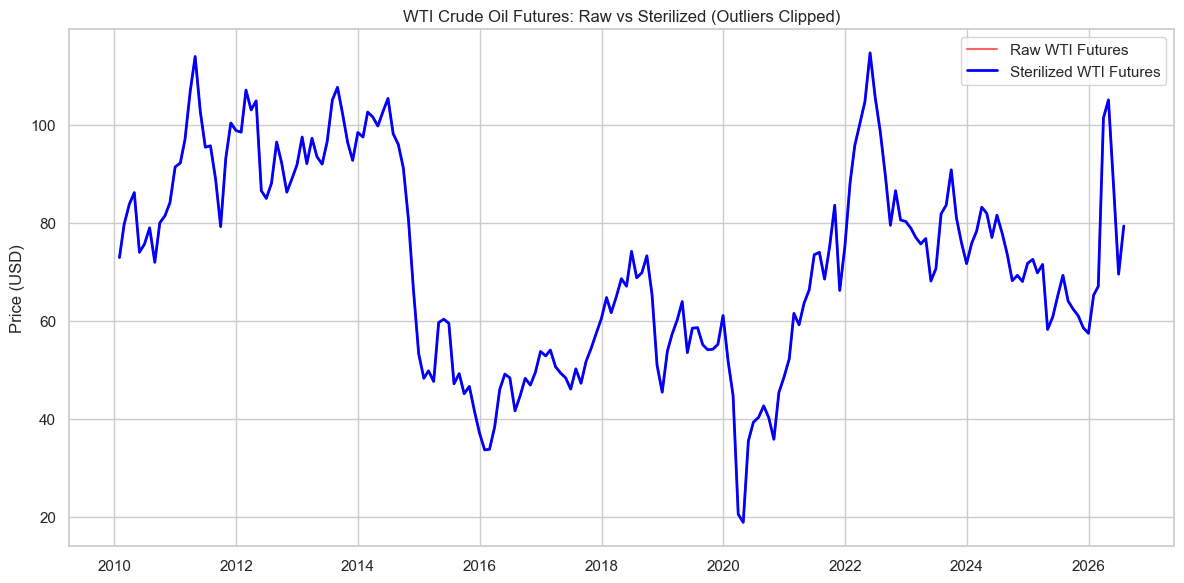

 -> Saved: cleaned_wti_price.png


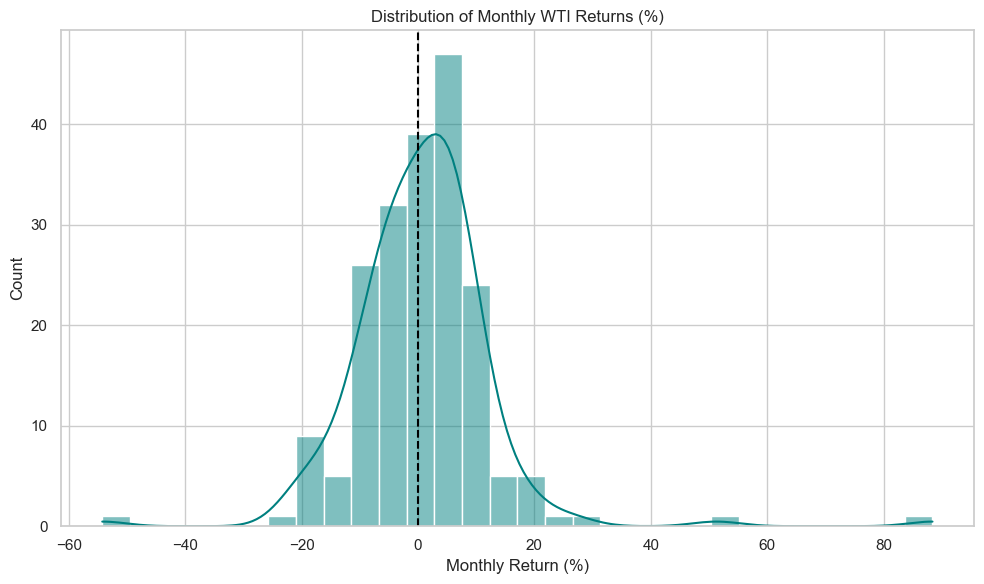

 -> Saved: returns_distribution.png


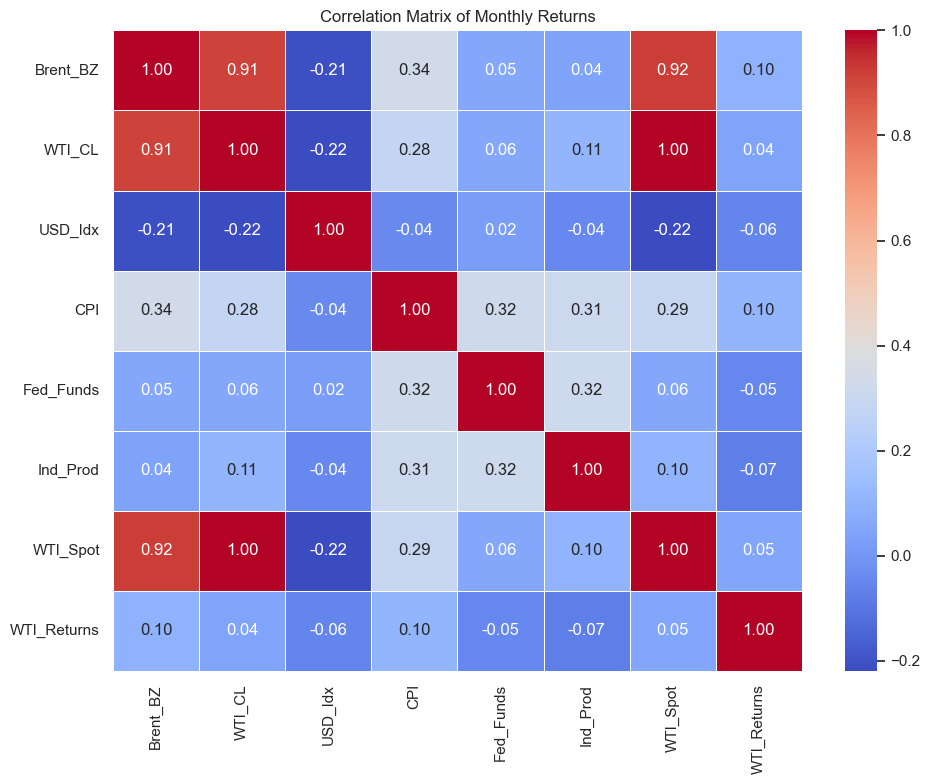

 -> Saved: correlation_heatmap.png


In [4]:
import os
import warnings
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# --- Directory Setup ---
base_dir = "/Users/alberto/Documents/projects/GWP_1/RiskManagement"
fig_dir = os.path.join(base_dir, "figures")
data_dir = os.path.join(base_dir, "data")
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(data_dir, exist_ok=True)

print("="*60)
print("STEP 3: DATA IDENTIFICATION AND IMPORT")
print("="*60)

# Define date range
end_date = datetime.today().strftime('%Y-%m-%d')
start_date = '2010-01-01'

# 1. Financial Data (Yahoo Finance)
print("\n[1/3] Downloading Financial Data (Yahoo Finance)...")
tickers = {
    'WTI_CL': 'CL=F',      # WTI Crude Futures
    'Brent_BZ': 'BZ=F',    # Brent Crude Futures
    'USD_Idx': 'DX-Y.NYB'  # US Dollar Index
}
fin_data = yf.download(list(tickers.values()), start=start_date, end=end_date, progress=False)['Close']
fin_data.rename(columns={v: k for k, v in tickers.items()}, inplace=True)
print(f" -> Financial data downloaded: {fin_data.shape}")

# 2. Macroeconomic Data (FRED)
print("\n[2/3] Downloading Macroeconomic Data (FRED)...")
fred_tickers = {
    'CPIAUCSL': 'CPI',         # Consumer Price Index
    'FEDFUNDS': 'Fed_Funds',   # Federal Funds Rate
    'INDPRO': 'Ind_Prod',      # Industrial Production
    'DCOILWTICO': 'WTI_Spot'   # WTI Spot Price (Daily)
}
try:
    macro_data = web.DataReader(list(fred_tickers.keys()), 'fred', start_date, end_date)
    macro_data.rename(columns=fred_tickers, inplace=True)
    print(f" -> Macro data downloaded: {macro_data.shape}")
except Exception as e:
    print(f" -> ERROR downloading FRED data: {e}")
    print(" -> Ensure 'pandas-datareader' is installed. Proceeding with Yahoo data only.")
    macro_data = pd.DataFrame()

# 3. Aligning to Monthly Frequency
print("\n[3/3] Aligning datasets to Monthly Frequency...")
# Resample daily data to monthly (using last business day)
fin_monthly = fin_data.resample('ME').last()
if not macro_data.empty:
    macro_monthly = macro_data.resample('ME').last()
    # Merge datasets
    df_raw = pd.merge(fin_monthly, macro_monthly, left_index=True, right_index=True, how='left')
else:
    df_raw = fin_monthly

# Drop columns with all NaNs
df_raw.dropna(axis=1, how='all', inplace=True)
print(f" -> Combined Raw Dataset Shape: {df_raw.shape}")
df_raw.to_csv(os.path.join(data_dir, "raw_combined_data.csv"))

print("\n" + "="*60)
print("STEP 5 & 6: DATA PREPROCESSING AND CLEANING")
print("="*60)

df_clean = df_raw.copy()
cleaning_log = []

# A) Extreme Outliers (IQR Method with factor of 3)
print("\n[A] Identifying and Clipping Extreme Outliers (IQR * 3)...")
outlier_count = 0
for col in df_clean.columns:
    if df_clean[col].dtype in ['float64', 'int64']:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR
        
        # Count outliers before clipping
        outliers = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
        if outliers > 0:
            df_clean[col] = np.clip(df_clean[col], lower_bound, upper_bound)
            outlier_count += outliers
            cleaning_log.append(f"Clipped {outliers} extreme outliers in {col}.")

print(f" -> Total extreme values clipped: {outlier_count}")

# B) Bad or Duplicated Data
print("\n[B] Checking for Duplicated Indices and Chronological Order...")
dupes = df_clean.index.duplicated().sum()
if dupes > 0:
    df_clean = df_clean[~df_clean.index.duplicated(keep='first')]
    cleaning_log.append(f"Removed {dupes} duplicated date indices.")
    print(f" -> Removed {dupes} duplicated indices.")
else:
    print(" -> No duplicated indices found.")
    
df_clean.sort_index(inplace=True)

# C) Missing Values (Time-based Interpolation + ffill/bfill)
print("\n[C] Handling Missing Values (Interpolation & Forward/Backward Fill)...")
missing_before = df_clean.isnull().sum().sum()
# Time-based interpolation is ideal for financial time series
df_clean.interpolate(method='time', inplace=True, limit_direction='both')
# Fill any remaining edges
df_clean.ffill(inplace=True)
df_clean.bfill(inplace=True)
missing_after = df_clean.isnull().sum().sum()

interpolated_vals = missing_before - missing_after
cleaning_log.append(f"Interpolated/Filled {interpolated_vals} missing values via time-based methods.")
print(f" -> Missing values before: {missing_before}")
print(f" -> Missing values after: {missing_after}")
print(f" -> Total values imputed/filled: {interpolated_vals}")

# Save Cleaned Data
df_clean.to_csv(os.path.join(data_dir, "sterilized_monthly_data.csv"))
print(f"\n -> Sterilized data saved to {data_dir}/sterilized_monthly_data.csv")

# Save Cleaning Log
with open(os.path.join(data_dir, "cleaning_log.txt"), 'w') as f:
    f.write("DATA CLEANING LOG (STERILISATION PROCESS)\n")
    f.write("="*40 + "\n")
    for item in cleaning_log:
        f.write(f"- {item}\n")
    f.write(f"\nFinal Dataset Shape: {df_clean.shape}\n")
    f.write(f"Date Range: {df_clean.index.min().strftime('%Y-%m-%d')} to {df_clean.index.max().strftime('%Y-%m-%d')}\n")

print("\n" + "="*60)
print("GENERATING INITIAL PLOTS (STEP 7 PREVIEW)")
print("="*60)

# Plot 1: Raw vs Cleaned WTI Price
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_raw['WTI_CL'], label='Raw WTI Futures', alpha=0.6, color='red')
ax.plot(df_clean['WTI_CL'], label='Sterilized WTI Futures', color='blue', linewidth=2)
ax.set_title('WTI Crude Oil Futures: Raw vs Sterilized (Outliers Clipped)')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "cleaned_wti_price.png"))
plt.show()
plt.close()
print(" -> Saved: cleaned_wti_price.png")

# Plot 2: Distribution of Monthly Returns
df_clean['WTI_Returns'] = df_clean['WTI_CL'].pct_change() * 100
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df_clean['WTI_Returns'].dropna(), kde=True, bins=30, ax=ax, color='teal')
ax.set_title('Distribution of Monthly WTI Returns (%)')
ax.set_xlabel('Monthly Return (%)')
ax.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "returns_distribution.png"))
plt.show()
plt.close()
print(" -> Saved: returns_distribution.png")

# Plot 3: Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_clean.pct_change().dropna().corr() # Correlation of returns
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix of Monthly Returns')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "correlation_heatmap.png"))
plt.show()
plt.close()
print(" -> Saved: correlation_heatmap.png")



# Cleaning data

Oil shape: (4156, 6)
Macro shape: (4368, 4)

Combined shape before cleaning: (199, 5)
Missing after cleaning: 0
Final cleaned shape: (199, 5)


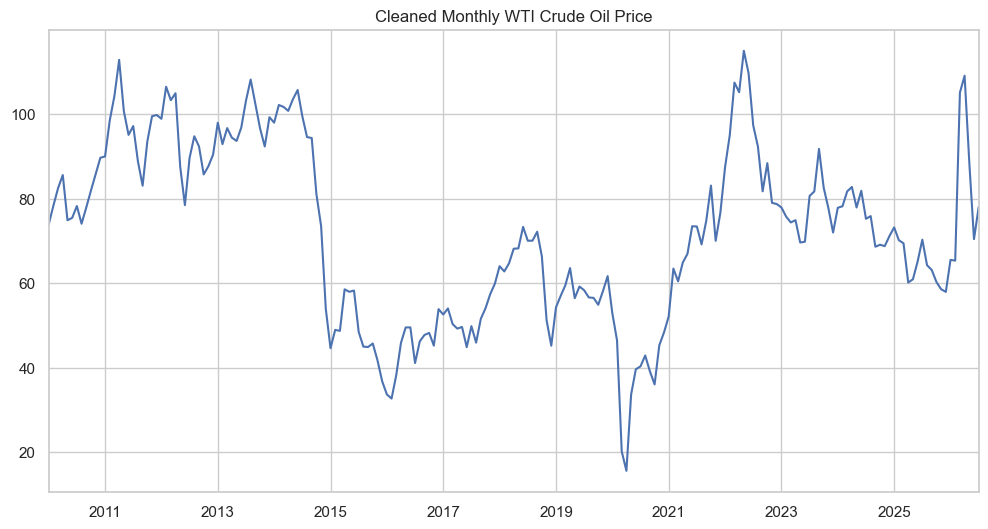

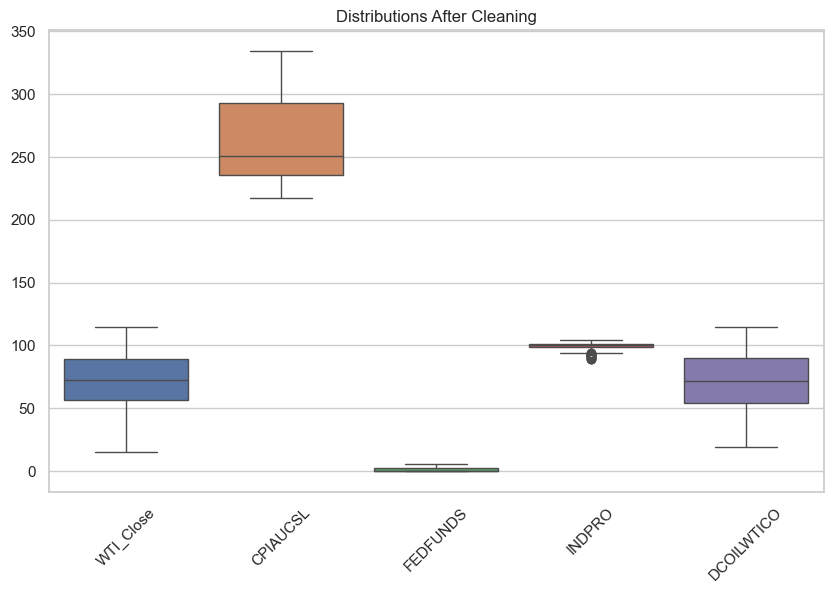

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

fig_dir = "/Users/alberto/Documents/projects/GWP_1/RiskManagement/GWP1/figures"
data_dir = "/Users/alberto/Documents/projects/GWP_1/RiskManagement/GWP1/data"

# Load oil (already fixed from your output)
oil = pd.read_csv(os.path.join(data_dir, "oil_prices.csv"), 
                  skiprows=3,
                  names=['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'],
                  parse_dates=['Date'], 
                  index_col='Date')

macro = pd.read_csv(os.path.join(data_dir, "fred_macro.csv"), 
                    parse_dates=['DATE'], index_col='DATE')

print("Oil shape:", oil.shape)
print("Macro shape:", macro.shape)

# Combine - use 'ME' instead of 'M'
df = pd.concat([
    oil['Close'].resample('ME').last().rename('WTI_Close'),
    macro.resample('ME').last()
], axis=1)

print("\nCombined shape before cleaning:", df.shape)

# Cleaning
def remove_outliers(series, factor=3.0):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return series.clip(Q1 - factor*IQR, Q3 + factor*IQR)

for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = remove_outliers(df[col])

df = df[~df.index.duplicated(keep='first')].sort_index()
df = df.interpolate(method='time').ffill().bfill()

print("Missing after cleaning:", df.isna().sum().sum())
print("Final cleaned shape:", df.shape)

df.to_csv(os.path.join(data_dir, "cleaned_oil_macro.csv"))

# Plots
plt.figure(figsize=(12,6))
df['WTI_Close'].plot(title="Cleaned Monthly WTI Crude Oil Price")
plt.savefig(os.path.join(fig_dir, "cleaned_wti_price.png"))
plt.show()
plt.close()

plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.title("Distributions After Cleaning")
plt.xticks(rotation=45)
plt.savefig(os.path.join(fig_dir, "post_cleaning_boxplot.png"))
plt.show()
plt.close()


# EDA

Loaded columns: ['WTI_Close', 'CPIAUCSL', 'FEDFUNDS', 'INDPRO', 'DCOILWTICO']
            WTI_Close  CPIAUCSL  FEDFUNDS   INDPRO  DCOILWTICO
2010-01-31  73.889999   217.488      0.11  89.3426       72.85
2010-02-28  78.330002   217.281      0.13  89.6779       79.72
2010-03-31  82.500000   217.353      0.16  90.2928       83.45
2010-04-30  85.580002   217.403      0.20  90.5991       86.07
2010-05-31  74.900002   217.290      0.20  91.8230       74.00


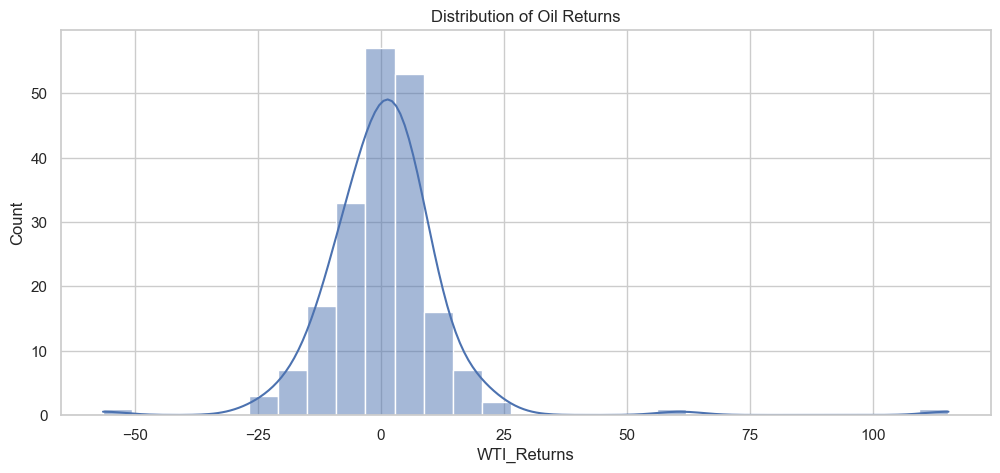

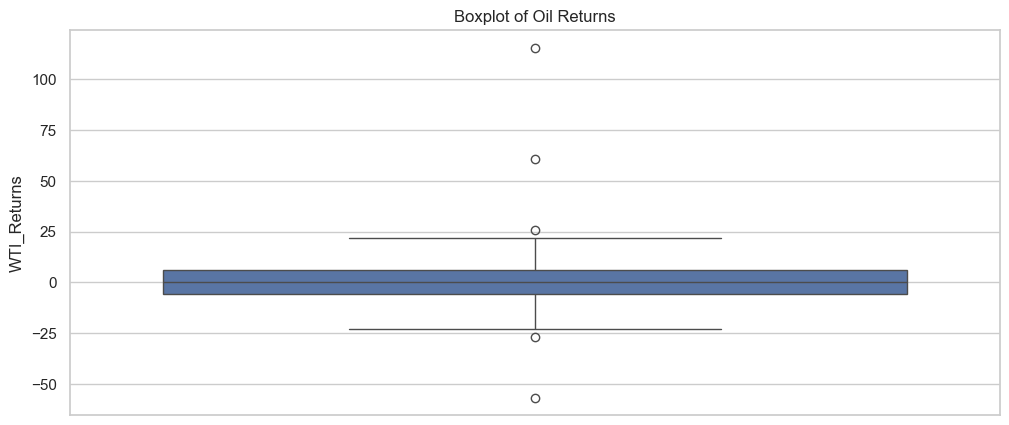

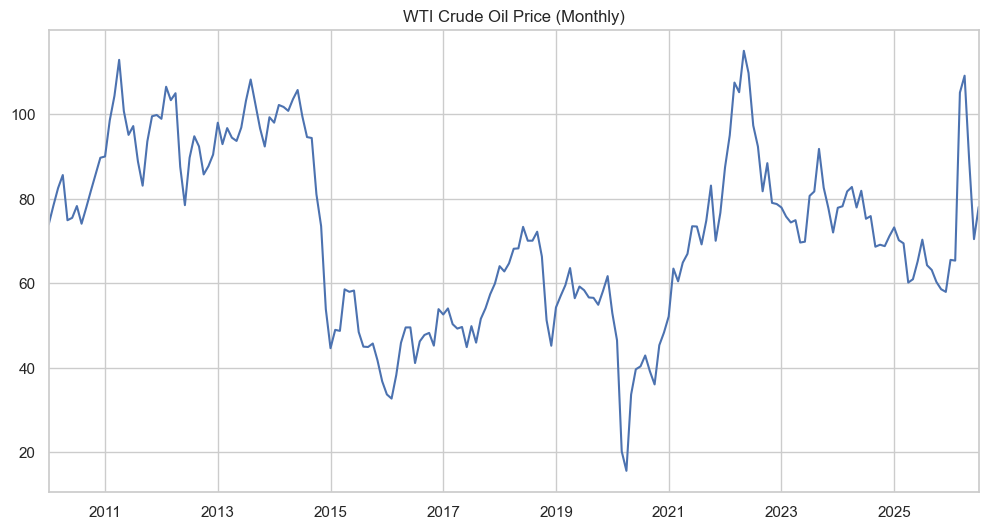

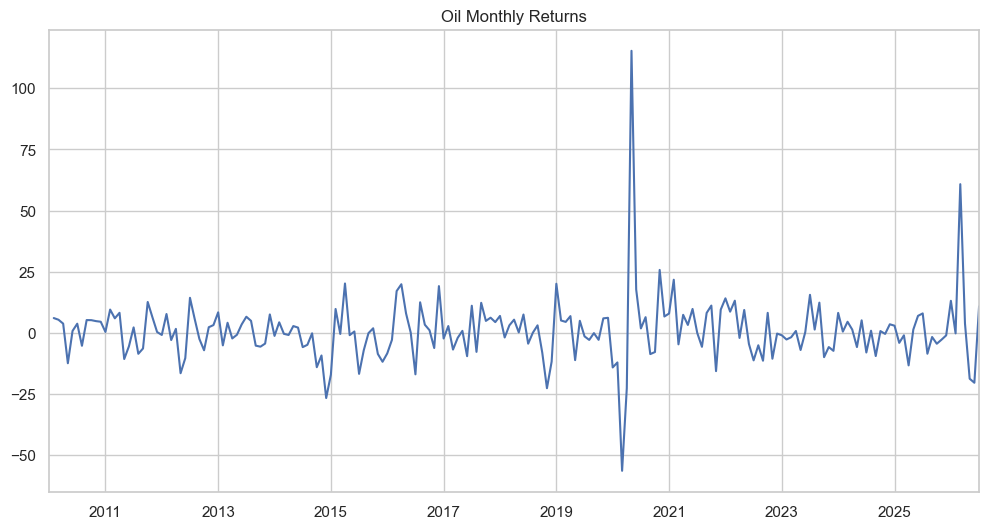

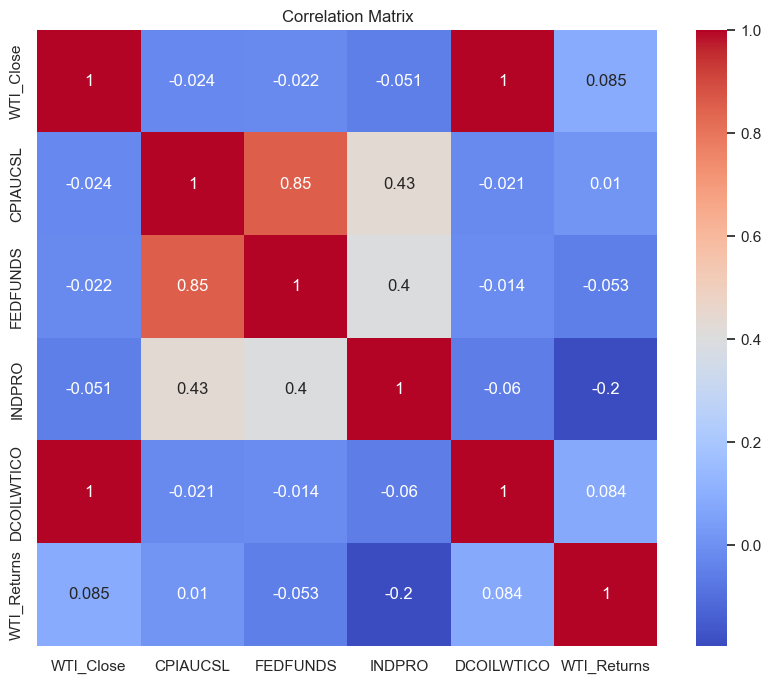


Key Statistics:
count    198.000000
mean       0.816871
std       13.391101
min      -56.485268
25%       -5.514131
50%        0.398526
75%        5.981320
max      115.345266
Name: WTI_Returns, dtype: float64

Lag-1 Autocorrelation of Returns: 0.08462552563994298


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

fig_dir = "/Users/alberto/Documents/projects/GWP_1/RiskManagement/GWP1/figures"
data_dir = "/Users/alberto/Documents/projects/GWP_1/RiskManagement/GWP1/data"

# Load without assuming column name
df = pd.read_csv(os.path.join(data_dir, "cleaned_oil_macro.csv"), 
                 parse_dates=[0], 
                 index_col=0)

print("Loaded columns:", df.columns.tolist())
print(df.head())

# Returns
df['WTI_Returns'] = df['WTI_Close'].pct_change() * 100

# Plots (same as before)
plt.figure(figsize=(12,5))
sns.histplot(df['WTI_Returns'].dropna(), kde=True)
plt.title("Distribution of Oil Returns")
plt.savefig(os.path.join(fig_dir, "returns_distribution.png"))
plt.show()
plt.close()

plt.figure(figsize=(12,5))
sns.boxplot(y=df['WTI_Returns'])
plt.title("Boxplot of Oil Returns")
plt.savefig(os.path.join(fig_dir, "returns_boxplot.png"))
plt.show()
plt.close()

plt.figure(figsize=(12,6))
df['WTI_Close'].plot(title="WTI Crude Oil Price (Monthly)")
plt.savefig(os.path.join(fig_dir, "wti_time_series.png"))
plt.show()
plt.close()

plt.figure(figsize=(12,6))
df['WTI_Returns'].plot(title="Oil Monthly Returns")
plt.savefig(os.path.join(fig_dir, "returns_time_series.png"))
plt.show()
plt.close()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.savefig(os.path.join(fig_dir, "correlation_heatmap.png"))
plt.show()
plt.close()

print("\nKey Statistics:")
print(df['WTI_Returns'].describe())
print("\nLag-1 Autocorrelation of Returns:", df['WTI_Returns'].autocorr(lag=1))